In [1]:
import os
import sys
import tempfile
import random
from glob import glob
from typing import List, Dict, Tuple, Optional
from PIL import Image

import monai
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from monai.data import Dataset, CacheDataset
from monai.transforms import (
    Compose,
    LoadImageD,
    EnsureChannelFirstD,
    ScaleIntensityRangeD,
    ResizeD,
    EnsureTypeD,
    RandFlipD,
    RandRotateD,
    RandAffineD,
    MapTransform,
)
from monai.networks.nets import EfficientNetBN
from monai.networks.nets import densenet121
from monai.visualize import GradCAM

# For robust AUC
from sklearn.metrics import roc_auc_score

/home/administrator/MonAi/my_torch_env/lib/python3.12/site-packages/cupy/_environment.py:596: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy-cuda12x, cupy-cuda13x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


In [59]:
image_label_map = pd.read_csv('data/train_df.csv')
bad_labels = pd.read_csv('data/cxr14_bad_labels.csv')
train_df = pd.read_csv("data/Data_Entry_2017.csv")
nih_encoded_df = pd.read_csv("data/NIH_Dataframe.csv")

In [60]:
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join('data',  'images*', '*', '*.png'))}

In [61]:
image_label_map.drop(['No Finding', 'Hernia'], axis = 1, inplace = True)
labels = image_label_map.columns[2:-1]
labels

Index(['Cardiomegaly', 'Emphysema', 'Effusion', 'Infiltration', 'Mass',
       'Nodule', 'Atelectasis', 'Pneumothorax', 'Pleural_Thickening',
       'Pneumonia', 'Fibrosis', 'Edema', 'Consolidation'],
      dtype='object')

In [62]:
image_label_map.iloc[:, 2:-1].sum().sort_values(ascending=False)

Infiltration          19869
Effusion              13287
Atelectasis           11543
Nodule                 6318
Mass                   5772
Pneumothorax           5293
Consolidation          4660
Pleural_Thickening     3379
Cardiomegaly           2775
Emphysema              2511
Edema                  2296
Fibrosis               1683
Pneumonia              1429
dtype: int64

In [63]:
nih_encoded_df.head()

,Cardiomegaly,Hernia,Infiltration,Nodule,Emphysema,Effusion,Atelectasis,Pleural_Thickening,Pneumothorax,Mass,Fibrosis,Consolidation,Edema,Pneumonia,img_ind
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,00000001_000.png
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,00000001_001.png
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,00000001_002.png
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,00000003_000.png
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,00000003_001.png


### Removing Samples with Bad Labels

In [64]:
train_df.rename(columns={"Image Index": "Index"}, inplace = True)
image_label_map.rename(columns={"Image Index": "Index"}, inplace = True)
train_df = train_df[~train_df.Index.isin(bad_labels.Index)]
train_df.shape

(111863, 12)

In [65]:
train_df['image_path'] = train_df['Index'].map(all_image_paths.get)
image_label_map['FilePath'] = image_label_map['Index'].map(all_image_paths.get)
image_label_map.shape

(111863, 16)

In [66]:
image_label_map.columns

Index(['Index', 'Patient ID', 'Cardiomegaly', 'Emphysema', 'Effusion',
       'Infiltration', 'Mass', 'Nodule', 'Atelectasis', 'Pneumothorax',
       'Pleural_Thickening', 'Pneumonia', 'Fibrosis', 'Edema', 'Consolidation',
       'FilePath'],
      dtype='object')

In [21]:
nih_encoded_df['FilePath'] = nih_encoded_df.img_ind.map(all_image_paths.get)
nih_encoded_df.shape

(51759, 16)

In [31]:
bad_cols = ["Hernia", "Fibrosis", "Consolidation"]
nih_encoded_df.drop(bad_cols, inplace=True, axis=1)

In [32]:
nih_encoded_df.columns

Index(['Cardiomegaly', 'Infiltration', 'Nodule', 'Emphysema', 'Effusion',
       'Atelectasis', 'Pleural_Thickening', 'Pneumothorax', 'Mass', 'Edema',
       'Pneumonia', 'img_ind', 'FilePath'],
      dtype='object')

In [33]:
LABELS = ['Cardiomegaly', 'Infiltration', 'Nodule', 'Emphysema', 'Effusion',
       'Atelectasis', 'Pleural_Thickening', 'Pneumothorax', 'Mass', 'Edema',
       'Pneumonia']
          
label_to_idx = {l: i for i, l in enumerate(LABELS)}
NUM_CLASSES = len(LABELS)

### Training

In [23]:
def make_items_from_df(df) -> List[Dict]:
    df = df.sample(frac=1)
    # if "FilePath" not in df.columns or "labels" not in df.columns:
    #     raise ValueError("CSV must have columns: image_path, labels")

    items = []
    for _, row in df.iterrows():
        img_path = str(row["FilePath"])
        y = row[LABELS].values.astype(np.float32)
        items.append({"image": img_path, "label": y})
    items
    return items


def train_val_split(
    items: List[Dict], val_frac: float = 0.1, seed: int = 42
) -> Tuple[List[Dict], List[Dict]]:
    rng = random.Random(seed)
    rng.shuffle(items)
    n_val = max(1, int(len(items) * val_frac))
    return items[n_val:], items[:n_val]

In [24]:
# -----------------------------
# 2) MONAI transform helpers
# -----------------------------
class ToGrayscaleD(MapTransform):
    """
    Ensures image is 1-channel. If loaded as RGB/multi-channel, converts by mean over channels.
    Expects channel-first [C,H,W].
    """

    def __call__(self, data):
        d = dict(data)
        x = d["image"]
        # x can be numpy or torch
        c = x.shape[0]
        if c > 1:
            x = x.mean(axis=0, keepdims=True)
        d["image"] = x
        return d


def get_transforms(img_size=(320, 320)):
    # Deterministic preprocessing (safe to cache)
    pre_tfms = Compose(
        [
            LoadImageD(keys="image", image_only=True),
            EnsureChannelFirstD(keys="image"),  # -> [C,H,W] or [1,H,W]
            ToGrayscaleD(keys="image"),
            # If your images are already float [0..1], adjust a_min/a_max accordingly
            ScaleIntensityRangeD(
                keys="image", a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True
            ),
            ResizeD(keys="image", spatial_size=img_size),
            EnsureTypeD(keys=("image", "label")),
        ]
    )

    # Random augmentations (DO NOT cache these)
    aug_tfms = Compose(
        [
            RandFlipD(keys="image", prob=0.5, spatial_axis=1),
            RandRotateD(keys="image", range_x=np.pi / 36, prob=0.3),
            RandAffineD(keys="image", prob=0.2, translate_range=(10, 10)),
            EnsureTypeD(keys=("image", "label")),
        ]
    )

    # Validation: deterministic only
    val_tfms = pre_tfms
    return pre_tfms, aug_tfms, val_tfms


def build_loaders(
        df: pd.DataFrame,
    batch_size: int = 32,
    num_workers: int = 8,
    cache_rate: float = 0.2,
    val_frac: float = 0.1,
    seed: int = 42,
    img_size=(320, 320),
):
    items = make_items_from_df(df)
    train_items, val_items = train_val_split(items, val_frac=val_frac, seed=seed)

    pre_tfms, aug_tfms, val_tfms = get_transforms(img_size=img_size)

    # Cache only deterministic preprocessing
    train_cached = CacheDataset(
        data=train_items,
        transform=pre_tfms,
        cache_rate=cache_rate,
        num_workers=num_workers,
    )
    # Apply augmentation after cache
    train_ds = Dataset(data=train_cached, transform=aug_tfms)

    # Val can be cached too (deterministic)
    val_ds = CacheDataset(
        data=val_items,
        transform=val_tfms,
        cache_rate=min(1.0, cache_rate),
        num_workers=num_workers,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return train_loader, val_loader, train_items, val_items


In [25]:
# -----------------------------
# 3) Metrics: robust per-class AUC
# -----------------------------
def compute_macro_auc(
    y_true: np.ndarray, y_prob: np.ndarray, eps: float = 1e-8
) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    y_true: [N,C] multi-hot (0/1)
    y_prob: [N,C] probabilities in [0,1]
    Returns:
      macro_auc (mean over valid classes),
      per_class_auc [C] with NaN for invalid classes,
      valid_mask [C] bool (True = class used)
    """
    C = y_true.shape[1]
    per_auc = np.full((C,), np.nan, dtype=np.float32)
    valid = np.zeros((C,), dtype=bool)

    for c in range(C):
        yt = y_true[:, c]
        yp = y_prob[:, c]
        # Need both positive and negative samples for ROC AUC
        if yt.max() == yt.min():
            continue
        try:
            per_auc[c] = roc_auc_score(yt, yp)
            valid[c] = True
        except Exception:
            # keep NaN
            pass

    if valid.any():
        macro = float(np.nanmean(per_auc))
    else:
        macro = float("nan")
    return macro, per_auc, valid


# -----------------------------
# 4) Loss: pos_weight for imbalance
# -----------------------------
def compute_pos_weight_from_items(train_items: List[Dict]) -> torch.Tensor:
    """
    pos_weight for BCEWithLogitsLoss:
      pos_weight[c] = (#neg[c] / #pos[c])
    """
    y = np.stack([it["label"] for it in train_items], axis=0)  # [N,C]
    pos = y.sum(axis=0)  # [C]
    neg = y.shape[0] - pos
    pos_weight = np.sqrt(neg / (pos + 1e-5))
    # pos_weight = neg / (pos + 1e-8)
    return torch.tensor(pos_weight, dtype=torch.float32)

In [34]:
csv_path = "data/train_df.csv"
out_path = "outputs/checkpoints/best_cxr_multilabel_4.pt"
epochs = 15
batch_size = 64
lr = 1e-4
num_workers = 8
cache_rate = 0.3
val_frac = 0.2
seed = 6
img_size =(320, 320)
amp = True
use_pos_weight = True

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [36]:
train_loader, val_loader, train_items, val_items = build_loaders(
    df=nih_encoded_df,
    batch_size=batch_size,
    num_workers=num_workers,
    cache_rate=cache_rate,
    val_frac=val_frac,
    seed=seed,
    img_size=img_size,
)

Loading dataset: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3105/3105 [00:13<00:00, 228.36it/s]


In [37]:
for batch in train_loader:
    print(batch["image"].shape)
    print(batch["label"].shape)
    break

torch.Size([64, 1, 320, 320])
torch.Size([64, 11])


In [38]:
num_classes = len(LABELS)
count = torch.zeros(num_classes)
n_samples = 0


y = np.stack([it["label"] for it in train_items], axis=0)  # [N,C]
count = y.sum(axis=0)  # [C]
n_samples = y.shape[0] 
class_prevalence_pct = (count / n_samples * 100)


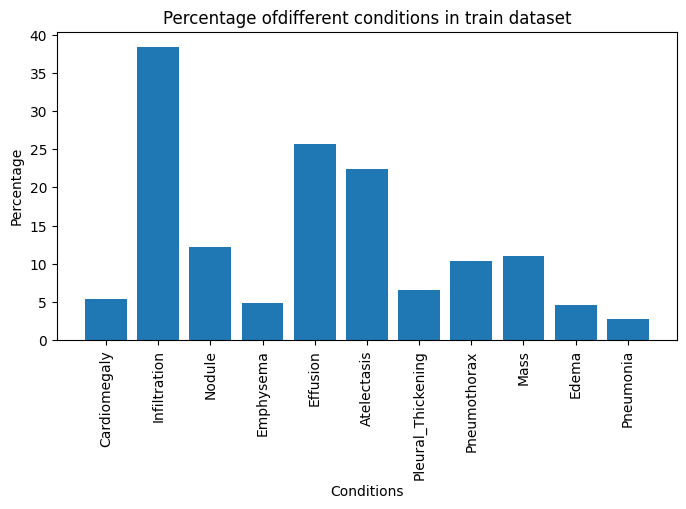

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.xticks(rotation = 90)
plt.bar(LABELS, class_prevalence_pct)
plt.title('Percentage ofdifferent conditions in train dataset')
plt.xlabel('Conditions')
plt.ylabel('Percentage')
plt.show()

In [40]:
def compute_class_freqs_from_loader(train_loader, num_classes, label_key="label", device="cpu"):
    pos_counts = torch.zeros(num_classes, dtype=torch.float32, device=device)
    n_samples = 0
    
    y = np.stack([it["label"] for it in train_items], axis=0)  # [N,C]
    pos_counts = y.sum(axis=0)  # [C]
    n_samples = y.shape[0] 
    print(pos_counts, n_samples)
    freq_pos = (pos_counts / n_samples)#.detach().cpu().numpy()
    freq_neg = 1.0 - freq_pos
    return freq_pos, freq_neg


freq_pos, freq_neg = compute_class_freqs_from_loader(
    train_loader=train_loader,
    num_classes=len(LABELS),
    label_key="label",
)

[ 2235. 15944.  5027.  2014. 10623.  9287.  2704.  4278.  4564.  1868.
  1143.] 41408


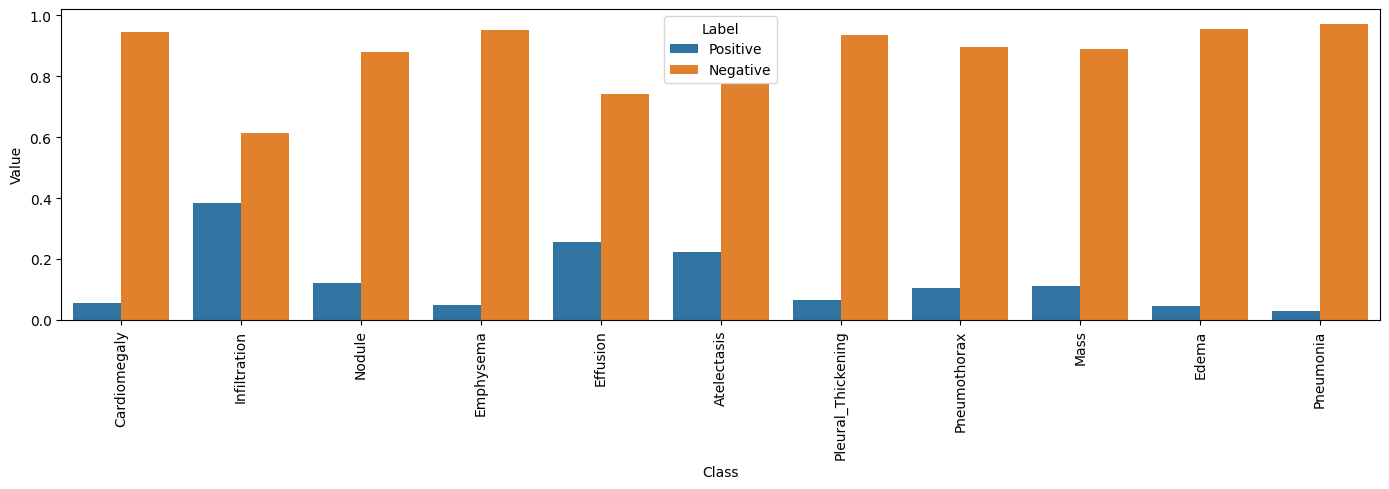

In [41]:
import seaborn as sns

# Positive rows
df_pos = pd.DataFrame({
    "Class": LABELS,
    "Label": "Positive",
    "Value": freq_pos
})

# Negative rows
df_neg = pd.DataFrame({
    "Class": LABELS,
    "Label": "Negative",
    "Value": freq_neg
})

# Combine
data = pd.concat([df_pos, df_neg], ignore_index=True)

# Plot
plt.figure(figsize=(14, 5))
sns.barplot(x="Class", y="Value", hue="Label", data=data)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

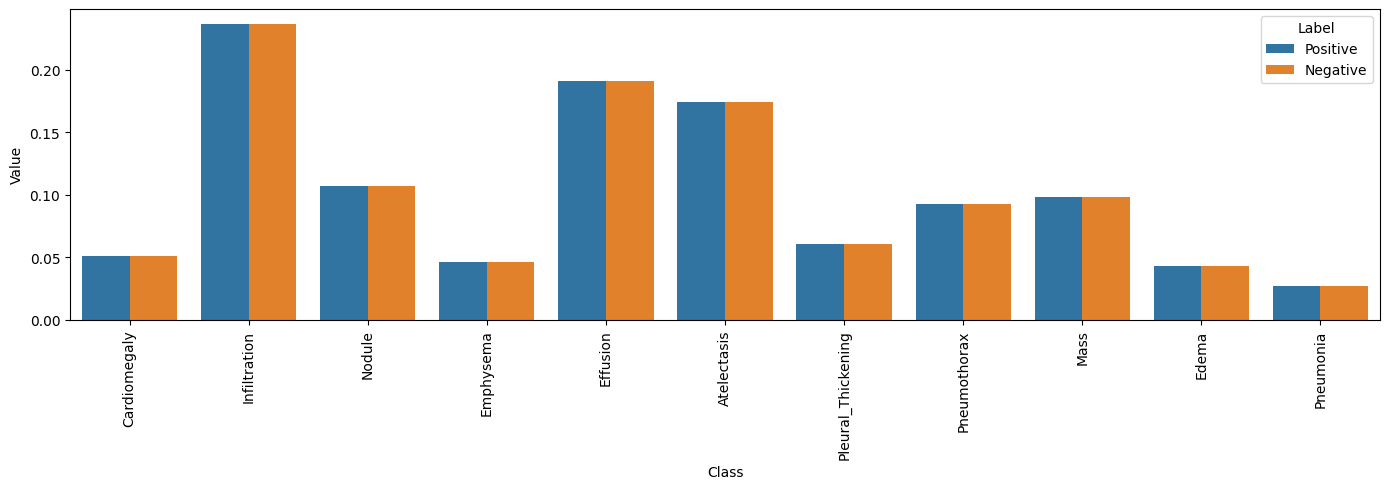

In [42]:
pos_weights = freq_neg
neg_weights = freq_pos
pos_contribution = freq_pos * pos_weights 
neg_contribution = freq_neg * neg_weights

# Positive rows
df_pos = pd.DataFrame({
    "Class": LABELS,
    "Label": "Positive",
    "Value": pos_contribution 

})

# Negative rows
df_neg = pd.DataFrame({
    "Class": LABELS,
    "Label": "Negative",
    "Value": neg_contribution
})

# Combine
data = pd.concat([df_pos, df_neg], ignore_index=True)

# Plot
plt.figure(figsize=(14, 5))
sns.barplot(x="Class", y="Value", hue="Label", data=data)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [43]:
# model = densenet121(spatial_dims=2, in_channels=1, out_channels=NUM_CLASSES).to(
#         device
#     )

# Instantiate the model (example uses B0)
model = EfficientNetBN(
    model_name="efficientnet-b0",
    spatial_dims=2,
    in_channels=1,
     pretrained=False,
    num_classes=NUM_CLASSES).to(
        device
    )

In [44]:
from torchinfo import summary

# A batch size of 1 is common for just getting the summary
input_size = (1, 1, 320, 320)

# Print the model summary
summary(model, input_size=input_size)

Layer (type:depth-idx)                             Output Shape              Param #
EfficientNetBN                                     [1, 11]                   --
├─ConstantPad2d: 1-1                               [1, 1, 321, 321]          --
├─Conv2d: 1-2                                      [1, 32, 160, 160]         288
├─BatchNorm2d: 1-3                                 [1, 32, 160, 160]         64
├─MemoryEfficientSwish: 1-4                        [1, 32, 160, 160]         --
├─Sequential: 1-5                                  [1, 320, 10, 10]          --
│    └─Sequential: 2-1                             [1, 16, 160, 160]         --
│    │    └─MBConvBlock: 3-1                       [1, 16, 160, 160]         1,448
│    └─Sequential: 2-2                             [1, 24, 80, 80]           --
│    │    └─MBConvBlock: 3-2                       [1, 24, 80, 80]           6,004
│    │    └─MBConvBlock: 3-3                       [1, 24, 80, 80]           10,710
│    └─Sequential: 2-3  

In [45]:
if use_pos_weight:
    pos_weight = compute_pos_weight_from_items(train_items).to(device)
    # pos_weight = torch.as_tensor(pos_contribution, dtype=torch.float32).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
else:
    loss_fn = nn.BCEWithLogitsLoss()

opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scaler = torch.amp.GradScaler(enabled=(amp and device.type == "cuda"), device=device)

In [46]:
LABELS, pos_weight

(['Cardiomegaly',
  'Infiltration',
  'Nodule',
  'Emphysema',
  'Effusion',
  'Atelectasis',
  'Pleural_Thickening',
  'Pneumothorax',
  'Mass',
  'Edema',
  'Pneumonia'],
 tensor([4.1865, 1.2638, 2.6902, 4.4227, 1.7023, 1.8598, 3.7833, 2.9461, 2.8413,
         4.6008, 5.9353], device='cuda:0'))

In [47]:
best_macro_auc = -1.0

for epoch in range(1, epochs + 1):
    # ---- train ----
    model.train()
    running_loss = 0.0
    n_seen = 0

    for batch in train_loader:
        x = batch["image"].to(device)  # [B,1,H,W]
        y = batch["label"].to(device)  # [B,C] float

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda",enabled=(amp and device.type == "cuda")):
            logits = model(x)  # [B,C]
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        # without GRADScale
        # logits = model(x)  # [B,C]
        # loss = loss_fn(logits, y)
        # loss.backward()
        # opt.step()


        running_loss += loss.item() * x.size(0)
        n_seen += x.size(0)

    train_loss = running_loss / max(1, n_seen)

    # ---- validate ----
    model.eval()
    probs_all = []
    y_all = []
    with torch.no_grad():
        for batch in val_loader:
            x = batch["image"].to(device)
            y = batch["label"].to(device)
            with torch.amp.autocast("cuda",enabled=(amp and device.type == "cuda")):
                logits = model(x)
                probs = torch.sigmoid(logits)
            
            # logits = model(x)
            # probs = torch.sigmoid(logits)
            
            probs_all.append(probs.detach().cpu())
            y_all.append(y.detach().cpu())

    probs_all = torch.cat(probs_all, dim=0).numpy()
    y_all = torch.cat(y_all, dim=0).numpy()

    macro_auc, per_auc, valid_mask = compute_macro_auc(y_all, probs_all)

    valid_count = int(valid_mask.sum())
    # show a short per-class summary for the rare labels
    hernia_auc = per_auc[label_to_idx["Pneumonia"]]
    nf_auc = per_auc[label_to_idx["Atelectasis"]]

    print(
        f"Epoch {epoch:03d}/{epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_macro_auc={macro_auc:.4f} (valid_classes={valid_count}/{NUM_CLASSES}) | "
        f"AUC(Atelectasis)={nf_auc if not np.isnan(nf_auc) else 'NA'} | "
        f"AUC(Pneumonia)={hernia_auc if not np.isnan(hernia_auc) else 'NA'}"
    )

    if not np.isnan(macro_auc) and macro_auc > best_macro_auc:
        best_macro_auc = macro_auc
        torch.save(
            {
                "model": model.state_dict(),
                "labels": LABELS,
                "img_size": img_size,
                "csv": os.path.abspath(csv_path),
            },
            out_path,
        )
        print(f"  ✅ Saved best checkpoint: {out_path} (macro_auc={best_macro_auc:.4f})")

print("Training done.")


Epoch 001/15 | train_loss=0.7282 | val_macro_auc=0.5678 (valid_classes=11/11) | AUC(Atelectasis)=0.5602738261222839 | AUC(Pneumonia)=0.5389418005943298
  ✅ Saved best checkpoint: outputs/checkpoints/best_cxr_multilabel_4.pt (macro_auc=0.5678)
Epoch 002/15 | train_loss=0.6699 | val_macro_auc=0.6150 (valid_classes=11/11) | AUC(Atelectasis)=0.5942186117172241 | AUC(Pneumonia)=0.5554901957511902
  ✅ Saved best checkpoint: outputs/checkpoints/best_cxr_multilabel_4.pt (macro_auc=0.6150)
Epoch 003/15 | train_loss=0.6498 | val_macro_auc=0.6244 (valid_classes=11/11) | AUC(Atelectasis)=0.6087132692337036 | AUC(Pneumonia)=0.5753614902496338
  ✅ Saved best checkpoint: outputs/checkpoints/best_cxr_multilabel_4.pt (macro_auc=0.6244)
Epoch 004/15 | train_loss=0.6401 | val_macro_auc=0.6345 (valid_classes=11/11) | AUC(Atelectasis)=0.6303955912590027 | AUC(Pneumonia)=0.5707321763038635
  ✅ Saved best checkpoint: outputs/checkpoints/best_cxr_multilabel_4.pt (macro_auc=0.6345)
Epoch 005/15 | train_loss=0.

In [48]:
# -----------------------------
# 6) Inference + Grad-CAM + overlay plotting
# -----------------------------

def disable_inplace_relu(m):
    for mod in m.modules():
        if isinstance(mod, nn.ReLU):
            mod.inplace = False

def find_last_conv_name(model: nn.Module) -> str:
    last = None
    for name, m in model.named_modules():
        if isinstance(m, nn.Conv2d):
            last = name
    if last is None:
        raise RuntimeError("No Conv2d layer found in model.")
    return last 

def load_checkpoint(ckpt_path: str, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(ckpt_path, map_location=device)
    # model = densenet121(spatial_dims=2, in_channels=1, out_channels=NUM_CLASSES).to(
    #     device
    # )
    model = EfficientNetBN(
            model_name="efficientnet-b0",
            spatial_dims=2,
            in_channels=1,
            pretrained=False,
            num_classes=NUM_CLASSES).to(
                device
            )
    model.load_state_dict(ckpt["model"])
    disable_inplace_relu(model)
    model.eval()
    img_size = tuple(ckpt.get("img_size", (320, 320)))
    return model, ckpt.get("labels", LABELS), img_size, device


def build_single_image_preprocess(img_size=(320, 320)):
    # Same deterministic preprocessing used in training/val
    pre_tfms = Compose(
        [
            LoadImageD(keys="image", image_only=True),
            EnsureChannelFirstD(keys="image"),
            ToGrayscaleD(keys="image"),
            ScaleIntensityRangeD(
                keys="image", a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True
            ),
            ResizeD(keys="image", spatial_size=img_size),
            EnsureTypeD(keys="image", track_meta=False),
        ]
    )
    return pre_tfms


def infer_with_gradcam(
    model: torch.nn.Module,
    image_path: str,
    class_idx: int,
    img_size=(320, 320),
    target_layers: str = "features",
):
    """
    Returns:
      probs: [C] float numpy
      cam:   [h,w] float numpy (0..1), typically lower-res than input
      img:   [H,W] float numpy (0..1) preprocessed image
    """
    device = next(model.parameters()).device
    pre = build_single_image_preprocess(img_size=img_size)

    sample = {"image": image_path}
    x = pre(sample)["image"]  # [1,H,W] torch tensor
    x = x.unsqueeze(0).to(device)  # [1,1,H,W]

    # Probabilities (no-grad)
    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits)[0].detach().cpu().numpy()
    
    target_layers = find_last_conv_name(model)
    print("Grad-CAM target layer:", target_layers)
    # Grad-CAM needs gradients (do NOT wrap in torch.no_grad)
    cam_gen = GradCAM(nn_module=model, target_layers=target_layers)
    cam = cam_gen(x, class_idx=class_idx)  # [1,1,h,w]
    cam = cam[0, 0].detach().cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    img = x[0, 0].detach().cpu().numpy()  # [H,W] 0..1
    return probs, cam, img


def overlay_cam(img: np.ndarray, cam: np.ndarray, alpha: float = 0.35) -> np.ndarray:
    """
    img: [H,W] float 0..1
    cam: [h,w] float 0..1
    output: [H,W] float 0..1 (simple blend; for nicer visuals use colormap overlay)
    """
    if cam.shape != img.shape:
        cam_t = torch.tensor(cam)[None, None, ...]
        cam_rs = torch.nn.functional.interpolate(
            cam_t, size=img.shape, mode="bilinear", align_corners=False
        )[0, 0].numpy()
    else:
        cam_rs = cam

    out = (1 - alpha) * img + alpha * cam_rs
    return np.clip(out, 0.0, 1.0)


def visualize_gradcam(image_path: str, ckpt_path: str, class_name: str):
    import matplotlib.pyplot as plt

    model, labels, img_size, device = load_checkpoint(ckpt_path)
    if class_name not in label_to_idx:
        raise ValueError(f"class_name must be one of: {labels}")

    class_idx = label_to_idx[class_name]
    probs, cam, img = infer_with_gradcam(
        model=model,
        image_path=image_path,
        class_idx=class_idx,
        img_size=img_size,
        target_layers="features",
    )

    blended = overlay_cam(img, cam, alpha=0.35)
    # probs = np.where(probs > 0.6, 1, 0)
    topk = np.argsort(-probs)[:5]
    print("Top-5 predicted labels:")
    for i in topk:
        print(f"  {labels[i]:>20s}: {probs[i]:.4f}")

    plt.figure()
    plt.title(f"Grad-CAM blend for: {class_name} (p={probs[class_idx]:.3f})")
    plt.imshow(blended, cmap="gray")
    plt.axis("off")
    plt.show()

    # Optional: show CAM heatmap itself
    plt.figure()
    plt.title("Grad-CAM heatmap")
    plt.imshow(img, cmap="gray")
    plt.imshow(
        torch.nn.functional.interpolate(
            torch.tensor(cam)[None, None, ...],
            size=img.shape,
            mode="bilinear",
            align_corners=False,
        )[0, 0].numpy(),
        cmap="jet",
        alpha=0.4,
    )
    plt.axis("off")
    plt.show()



In [81]:
# ---- validate ----
# modelinf, labels, img_size, device = load_checkpoint(out_path)
labels, img_size, device = LABELS, img_size, device
model.eval()
probs_all = []
y_all = []
with torch.no_grad():
    for batch in val_loader:
        x = batch["image"].to(device)
        y = batch["label"].to(device)
        # with torch.amp.autocast("cuda",enabled=(amp and device.type == "cuda")):
        logits = model(x)
        probs = torch.sigmoid(logits)

        probs_all.append(probs.detach().cpu())
        y_all.append(y.detach().cpu())

probs_all = torch.cat(probs_all, dim=0).numpy()
y_all = torch.cat(y_all, dim=0).numpy()

In [82]:
y_pred_all = np.where(probs_all > 0.4, 1, 0)

In [83]:
from sklearn.metrics import roc_auc_score

for i, n in enumerate(LABELS):
  print(LABELS[i])
  print(i, roc_auc_score(y_all[:, i], y_pred_all[:, i]))
  print('---------')

Cardiomegaly
0 0.6424478209831531
---------
Infiltration
1 0.6058986629858073
---------
Nodule
2 0.6057347671769987
---------
Emphysema
3 0.6310541163602266
---------
Effusion
4 0.6868550682525143
---------
Atelectasis
5 0.6362074928217654
---------
Pleural_Thickening
6 0.5509809772416318
---------
Pneumothorax
7 0.7156739904142544
---------
Mass
8 0.6173940762643345
---------
Edema
9 0.5711508858317917
---------
Pneumonia
10 0.4988571996422538
---------


In [84]:
from sklearn.metrics import classification_report

print(classification_report(y_all, y_pred_all, target_names=labels, zero_division=0))

                    precision    recall  f1-score   support

      Cardiomegaly       0.48      0.30      0.37       541
      Infiltration       0.47      0.73      0.57      3950
            Nodule       0.21      0.45      0.29      1304
         Emphysema       0.23      0.32      0.27       502
          Effusion       0.46      0.64      0.53      2694
       Atelectasis       0.33      0.65      0.43      2272
Pleural_Thickening       0.21      0.14      0.17       681
      Pneumothorax       0.27      0.61      0.37      1024
              Mass       0.30      0.34      0.32      1218
             Edema       0.22      0.17      0.19       435
         Pneumonia       0.00      0.00      0.00       288

         micro avg       0.36      0.55      0.43     14909
         macro avg       0.29      0.40      0.32     14909
      weighted avg       0.36      0.55      0.43     14909
       samples avg       0.37      0.55      0.41     14909



Confusion Matrix as a NumPy array:


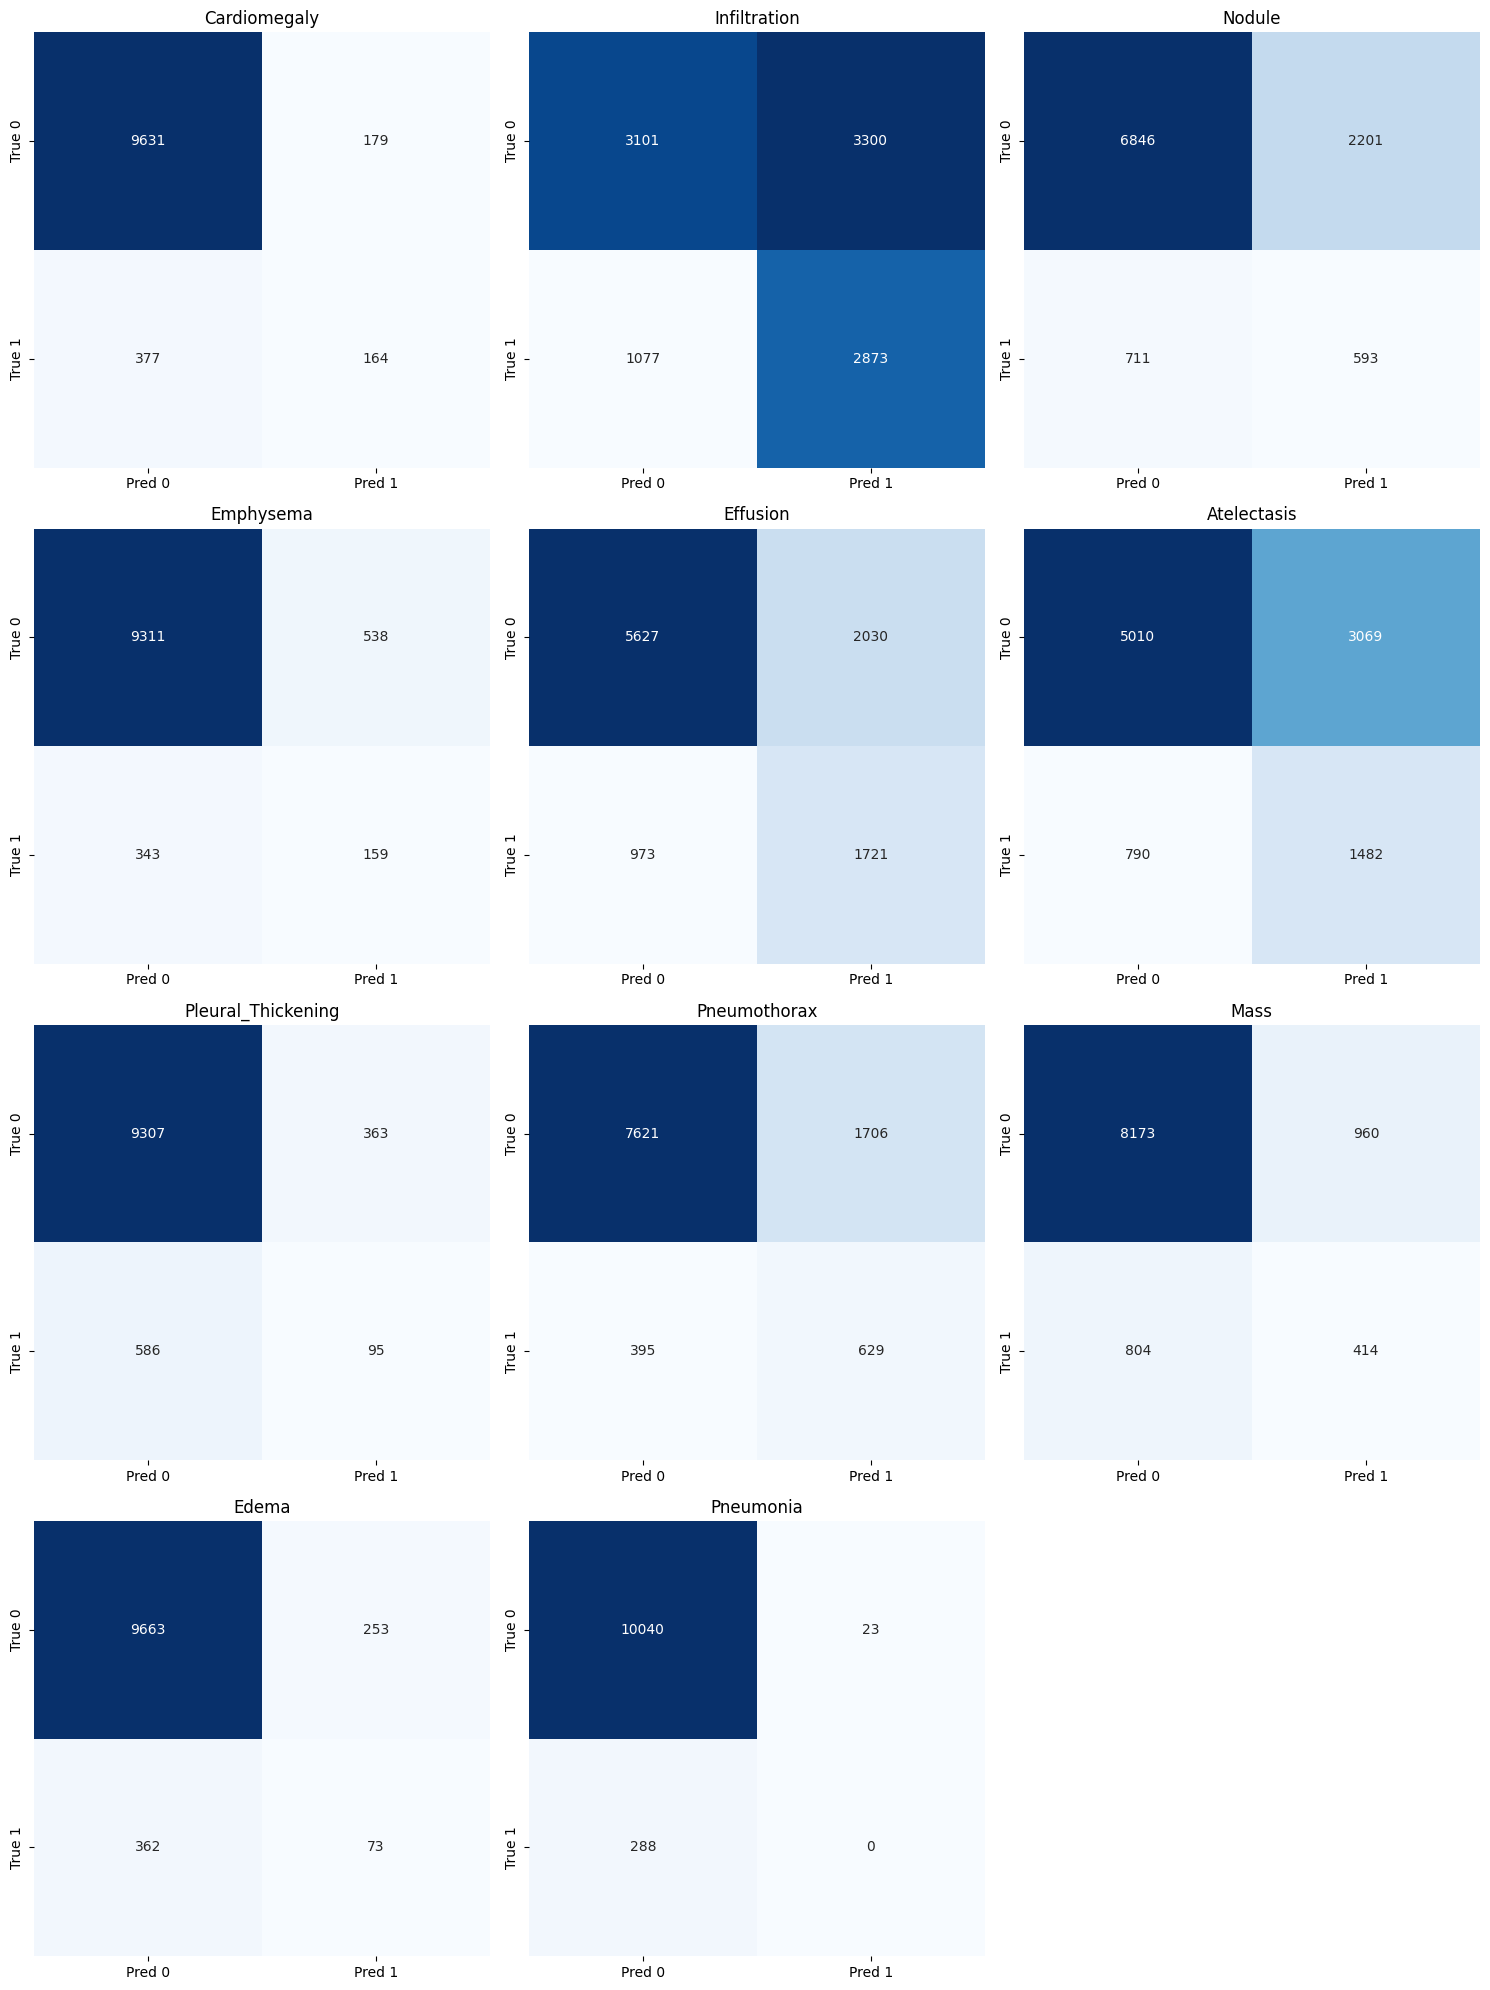

In [90]:
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# The confusion_matrix function returns a 2D numpy array
mcm = multilabel_confusion_matrix(y_all, y_pred_all)
print("Confusion Matrix as a NumPy array:")
# print(cm)

n_classes = len(labels)
cols = 3
rows = int(np.ceil(n_classes / cols))

plt.figure(figsize=(15, 5 * rows))

for i in range(n_classes):
    plt.subplot(rows, cols, i + 1)
    sns.heatmap(
        mcm[i],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(labels[i])

plt.tight_layout()
plt.show()

Text(0, 0.5, 'True Positive Rate')

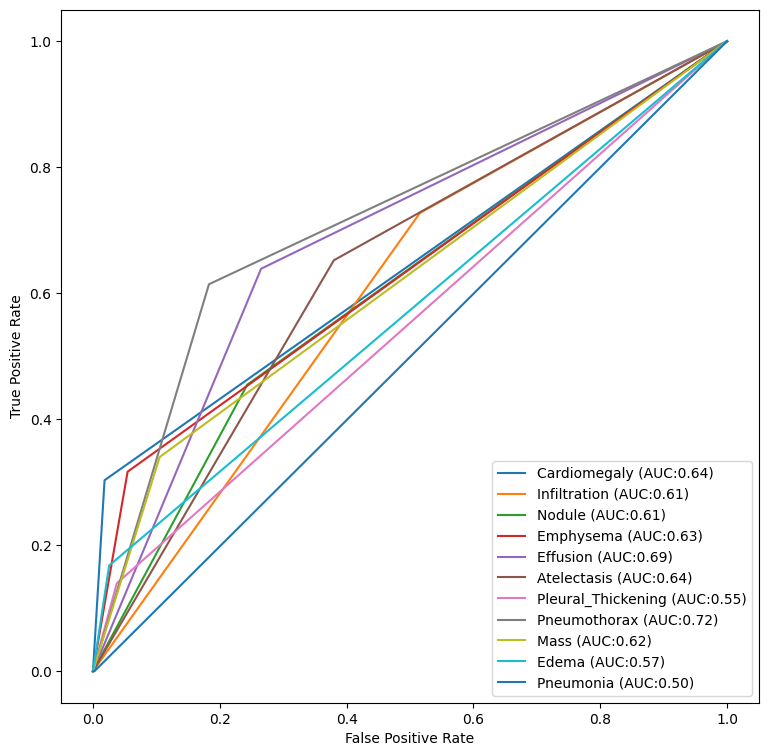

In [91]:
from sklearn.metrics import roc_curve, auc
fig, c_ax = plt.subplots(1,1, figsize = (9, 9))
for (idx, c_label) in enumerate(LABELS):
    fpr, tpr, thresholds = roc_curve(y_all[:,idx].astype(int), y_pred_all[:,idx])
    c_ax.plot(fpr, tpr, label = '%s (AUC:%0.2f)'  % (c_label, auc(fpr, tpr)))
c_ax.legend()
c_ax.set_xlabel('False Positive Rate')
c_ax.set_ylabel('True Positive Rate')

In [55]:
LABELS

['Cardiomegaly',
 'Infiltration',
 'Nodule',
 'Emphysema',
 'Effusion',
 'Atelectasis',
 'Pleural_Thickening',
 'Pneumothorax',
 'Mass',
 'Edema',
 'Pneumonia']

In [85]:
cls_label = "Pneumothorax"
tmp_df = train_df[train_df["Finding Labels"].str.contains(cls_label)]
tmp_df.shape

(5293, 13)

True Label: Pneumothorax 

Grad-CAM target layer: _conv_head
Top-5 predicted labels:
          Pneumothorax: 0.6761
             Emphysema: 0.6332
           Atelectasis: 0.4113
    Pleural_Thickening: 0.3581
          Infiltration: 0.3207


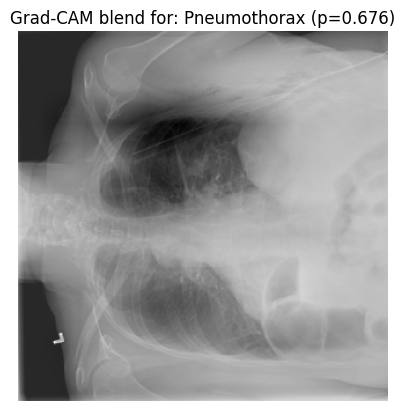

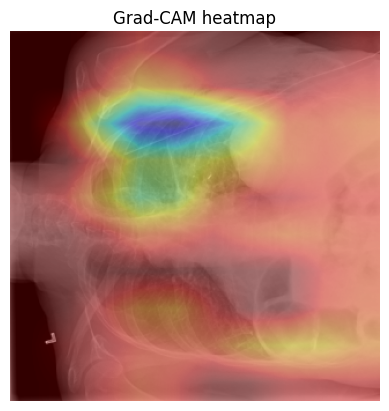

In [86]:
i=786

img_path = tmp_df.iloc[i]["image_path"]
# cls_label = tmp_df.iloc[i]["Finding Labels"]
print("True Label:", tmp_df.iloc[i]["Finding Labels"], "\n")
# cls_label = cls_label.split("|")[0]
# cls_label = "Infiltration"
visualize_gradcam(
        image_path=img_path,
        ckpt_path=out_path,
        class_name=cls_label,
    )

In [35]:
SAMPLES = 1000
val_datas = val_loader.dataset.data[:SAMPLES]
len(val_datas)

1000

In [21]:


cleaned_data = [entry for entry in val_datas if np.any(entry['label'] != 0)]

len(cleaned_data)

451

In [22]:
cleaned_data

[{'image': 'data/images_008/images/00017126_002.png',
  'label': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        dtype=float32)},
 {'image': 'data/images_004/images/00009193_000.png',
  'label': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        dtype=float32)},
 {'image': 'data/images_005/images/00011427_000.png',
  'label': array([0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        dtype=float32)},
 {'image': 'data/images_009/images/00020673_045.png',
  'label': array([0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        dtype=float32)},
 {'image': 'data/images_002/images/00001582_005.png',
  'label': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        dtype=float32)},
 {'image': 'data/images_010/images/00023853_000.png',
  'label': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        dtype=float32)},
 {'image': 'data/images_012/images/00029244_002.png',
  'label': array([0., 

In [23]:
import shutil
from pathlib import Path

dst_dir = Path("outputs/val_samples")
dst_dir.mkdir(parents=True, exist_ok=True)

new_val_datas = []
for data in cleaned_data[:200]:
    dta = data.copy()
    filename = os.path.basename(dta["image"])
    # print(data['image'])
    shutil.copy(dta["image"], dst_dir / filename)
    dta["image"] = filename
    new_val_datas.append(dta)
    # break

In [24]:
import pickle

with open("outputs/val_samples.pkl", "wb") as f:
    pickle.dump(new_val_datas, f)

In [25]:
np.save("outputs/val_samples.npy", new_val_datas)